In [1]:
import pandas as pd
import numpy as np

# Number of rows
n = 400

# Generate synthetic data
np.random.seed(42)  # reproducibility
user_id = np.arange(1, n+1)
gender = np.random.choice(['Male', 'Female'], size=n)
age = np.random.randint(18, 60, size=n)
estimated_salary = np.random.randint(20000, 100000, size=n)
purchased = np.random.choice([0, 1], size=n)

# Create DataFrame
df = pd.DataFrame({
    'UserID': user_id,
    'Gender': gender,
    'Age': age,
    'EstimatedSalary': estimated_salary,
    'Purchased': purchased
})
df.to_csv("5-Social_Network_Adv.csv", index=False)


In [2]:

import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score

In [4]:
data=pd.read_csv("5-Social_Network_Adv.csv")

In [6]:
print(data)

     UserID  Gender  Age  EstimatedSalary  Purchased
0         1    Male   41            82292          0
1         2  Female   28            43833          0
2         3    Male   25            24158          0
3         4    Male   53            82680          0
4         5    Male   55            40309          1
..      ...     ...  ...              ...        ...
395     396  Female   22            57148          0
396     397  Female   50            24757          0
397     398  Female   18            39097          1
398     399  Female   35            30395          0
399     400    Male   49            36241          1

[400 rows x 5 columns]


In [7]:
x=data.iloc[:,[2,3]].values
y=data.iloc[:,4].values

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [11]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [13]:
classifier=LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [14]:
y_pred=classifier.predict(x_test)

In [15]:
cm=confusion_matrix(y_test,y_pred)

In [17]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [20]:
accuracy=accuracy_score(y_test,y_pred)
error_rate=1-accuracy
precision=precision_score(y_test,y_pred)


In [21]:
f1=f1_score(y_test,y_pred)

NameError: name 'f1_score' is not defined

In [23]:
print("Confusion Matrics:",cm)
print("True Positive:",TP)
print("True Negative:",TN)
print("False Positive:",FP)
print("False Negative:",FN)
print("Accuracy:",accuracy)
print("Error Rate:",error_rate)
print("Precision:",precision)

Confusion Matrics: [[36 12]
 [35 17]]
True Positive: 17
True Negative: 36
False Positive: 12
False Negative: 35
Accuracy: 0.53
Error Rate: 0.47
Precision: 0.5862068965517241


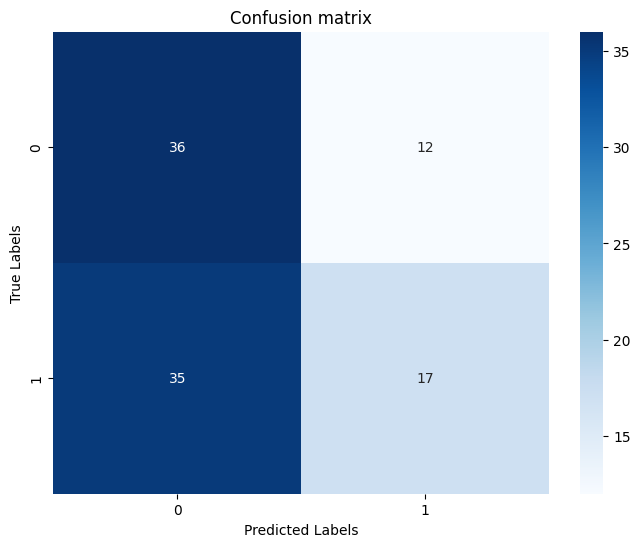

In [24]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,cmap="Blues",fmt='g')
plt.title('Confusion matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()